Sales Summary:
   product  total_quantity  total_revenue
0   Apples              17            8.5
1  Bananas              15            4.5
2  Oranges               8            3.2


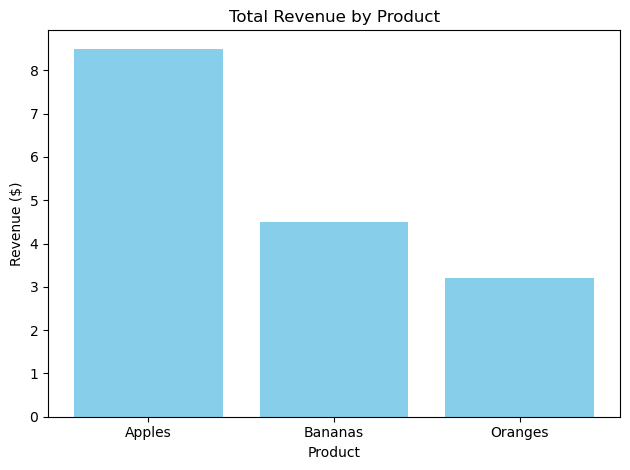

In [1]:
# 📌 This program reads sales info from a small database and shows totals

import sqlite3               # To talk to the database
import pandas as pd          # To organize data (tables)
import matplotlib.pyplot as plt  # To make bar charts

# Step 1: Connect to a database file (will create it if it doesn't exist)
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

# Step 2: Create a table called "sales" with columns: product, quantity, price
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

# Step 3: Insert sample data into the table
sample_data = [
    ('Apples', 10, 0.50),
    ('Bananas', 5, 0.30),
    ('Oranges', 8, 0.40),
    ('Apples', 7, 0.50),
    ('Bananas', 10, 0.30),
]

cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()  # Save the changes to the file

# Step 4: Get total quantity and revenue per product using SQL
query = '''
    SELECT 
        product, 
        SUM(quantity) AS total_quantity, 
        SUM(quantity * price) AS total_revenue
    FROM sales
    GROUP BY product
'''
df = pd.read_sql_query(query, conn)

# Step 5: Show the result in the terminal
print("Sales Summary:")
print(df)

# Step 6: Draw a bar chart showing total revenue per product
plt.bar(df['product'], df['total_revenue'], color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

# Step 7: Close the connection to the database
conn.close()


In [2]:
python sales_summary.py


SyntaxError: invalid syntax (3229770530.py, line 1)